In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from miss_alignment.data.shift_generation import JitterGenerator, OutlierGenerator, TrajectoryGenerator, FractureGenerator

sns.set(context='talk', style='ticks')

In [2]:
# Setup for shift visualization
n_tilts_plot = 35
tilt_angles_plot = np.linspace(-51, 51, n_tilts_plot)

## Reconstructions with Different Shift Types

In this section, we load a tilt-series and create reconstructions at a specific 3D position with different types of shifts applied.

In [3]:
import torch
from pathlib import Path
from miss_alignment.data.io import TiltSeriesData
from miss_alignment.data.shift_generation import project_shifts_3d_to_2d
from torch_affine_utils.transforms_3d import Ry, Rz
from warpylib.tilt_series.reconstruct_volume import preprocess_tilt_data

# Load tilt-series data
xml_path = Path("/home/marten/data/download/shrec_zenodo/ground_truth/model_1.xml") 
tilt_series_data = TiltSeriesData(xml_metadata_path=xml_path)
tilt_series, images, pixel_size = tilt_series_data.load_metadata_and_stack(downsample=1)
tilt_series.volume_dimensions_physical = torch.tensor((512 * 10, 512 * 10, 180 * 10))
tilt_series.image_dimensions_physical = torch.tensor((512 * 10, 512 * 10))
tilt_series.size_rounding_factors = torch.tensor([1.,] * 3)


# Move to GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"
tilt_series = tilt_series.to(device)
images = images.to(device)

# Preprocess images
patch_size = 96
images = preprocess_tilt_data(
    tilt_data=images,
    normalize=True,
    invert=False,
    subvolume_size=patch_size,
)

# Select a 3D position for reconstruction (center of volume by default)
x_dim, y_dim, z_dim = tilt_series.volume_dimensions_physical
reconstruction_location = torch.tensor([[x_dim/2, y_dim/2, z_dim/2]], device=device)

print(f"Loaded tilt-series with {len(tilt_series.angles)} images")
print(f"Pixel size: {pixel_size:.2f} Å")
print(f"Volume dimensions: {x_dim:.0f} x {y_dim:.0f} x {z_dim:.0f} Å")
print(f"Reconstruction location: {reconstruction_location[0].cpu().numpy()}")

Loaded tilt-series with 61 images
Pixel size: 10.00 Å
Volume dimensions: 5120 x 5120 x 1800 Å
Reconstruction location: [2560. 2560.  900.]


In [4]:
# Setup for applying shifts
n_tilts = len(tilt_series.angles)

# Calculate projection matrices for 3D to 2D shift projection
r0 = Ry(-tilt_series.angles, zyx=True)
r1 = Rz(tilt_series.tilt_axis_angles, zyx=True)
rotation_matrices = r1 @ r0
projection_matrices = rotation_matrices[..., 1:3, :3]

# Store original alignment parameters
original_offset_x = tilt_series.tilt_axis_offset_x.clone()
original_offset_y = tilt_series.tilt_axis_offset_y.clone()

In [8]:
# Generate all shifts upfront for better control
# You can modify these generators or add random seeds for reproducibility

# Create shift generators
jitter_generator = JitterGenerator(jitter_max_std=2.0)
trajectory_generator = TrajectoryGenerator(trajectory_max_shift=10.0)
outlier_generator = OutlierGenerator(outlier_max_shift=20)
fracture_generator = FractureGenerator(fracture_max_shift=20)

# Generate 3D shifts for each type
shifts_dict = {}
shifts_dict['No shifts'] = None
shifts_dict['Jitter'] = jitter_generator(n_tilts, device)
shifts_dict['Trajectory'] = trajectory_generator(n_tilts, device)
shifts_dict['Outliers'] = outlier_generator(n_tilts, device)
shifts_dict['Fractures'] = fracture_generator(n_tilts, device)

# Create combined shifts by summing all individual shift types
shifts_dict['Combined'] = (
    shifts_dict['Jitter'] +
    shifts_dict['Trajectory'] +
    shifts_dict['Outliers'] +
    shifts_dict['Fractures']
)

print("Generated shifts for all types:")
for shift_type, shifts in shifts_dict.items():
    if shifts is not None:
        max_shift = shifts[:, 0].abs().max().item()
        print(f"  {shift_type}: max Z-shift = {max_shift:.2f} pixels")
    else:
        print(f"  {shift_type}: no shifts applied")

Generated shifts for all types:
  No shifts: no shifts applied
  Jitter: max Z-shift = 3.17 pixels
  Trajectory: max Z-shift = 2.51 pixels
  Outliers: max Z-shift = 16.28 pixels
  Fractures: max Z-shift = 2.13 pixels
  Combined: max Z-shift = 18.34 pixels


In [9]:
# Perform reconstructions using the pre-generated shifts
reconstructions = {}

def apply_shifts_and_reconstruct(shifts_3d, label):
    """Apply pre-generated shifts and perform reconstruction."""
    # Reset to original alignment
    tilt_series.tilt_axis_offset_x = original_offset_x.clone()
    tilt_series.tilt_axis_offset_y = original_offset_y.clone()
    
    if shifts_3d is not None:
        # Project to 2D and convert to Angstroms
        shifts_2d = project_shifts_3d_to_2d(shifts_3d, projection_matrices)
        shifts_angstrom = shifts_2d * pixel_size
        
        # Apply shifts (Y is dim 0, X is dim 1)
        tilt_series.tilt_axis_offset_y += shifts_angstrom[:, 0]
        tilt_series.tilt_axis_offset_x += shifts_angstrom[:, 1]
    
    # Perform reconstruction
    reconstruction = tilt_series.reconstruct_subvolumes_single(
        tilt_data=images,
        coords=reconstruction_location,
        pixel_size=pixel_size,
        size=patch_size,
        apply_ctf=False,
        angles=torch.tensor([0.0, 0.0, 0.0], device=device),
        oversampling=2.0,
    ).squeeze()
    
    print(f"Completed reconstruction: {label}")
    return reconstruction.cpu()

# Perform reconstructions for all shift types
for shift_type, shifts_3d in shifts_dict.items():
    reconstructions[shift_type] = apply_shifts_and_reconstruct(shifts_3d, shift_type)

# Reset to original alignment
tilt_series.tilt_axis_offset_x = original_offset_x
tilt_series.tilt_axis_offset_y = original_offset_y

Completed reconstruction: No shifts
Completed reconstruction: Jitter
Completed reconstruction: Trajectory
Completed reconstruction: Outliers
Completed reconstruction: Fractures
Completed reconstruction: Combined


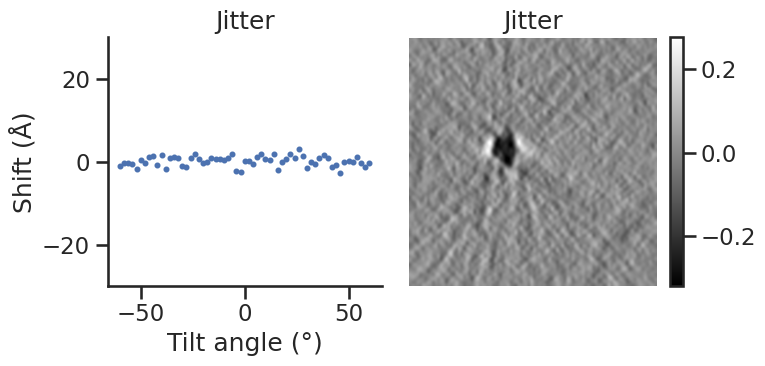

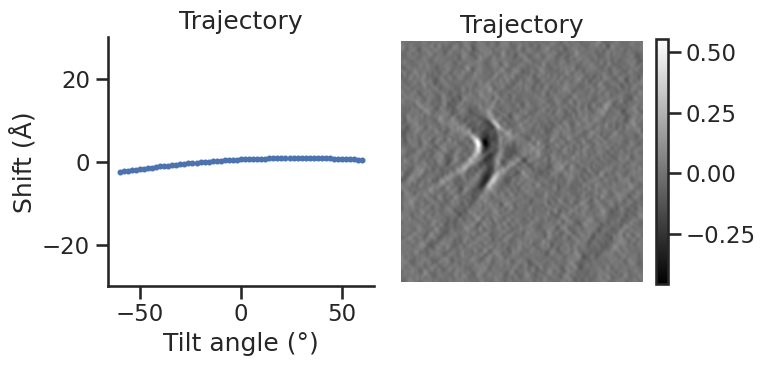

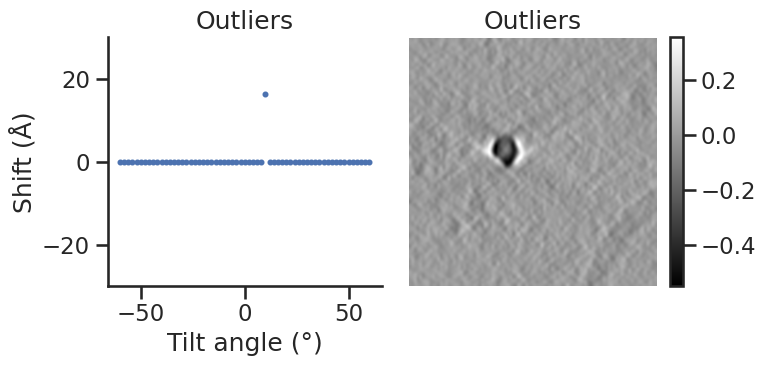

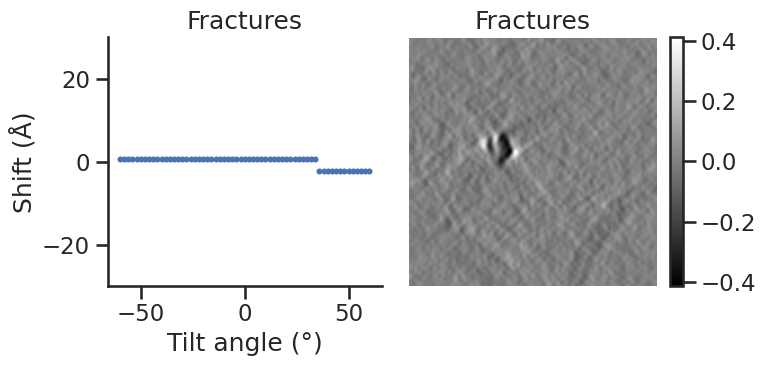

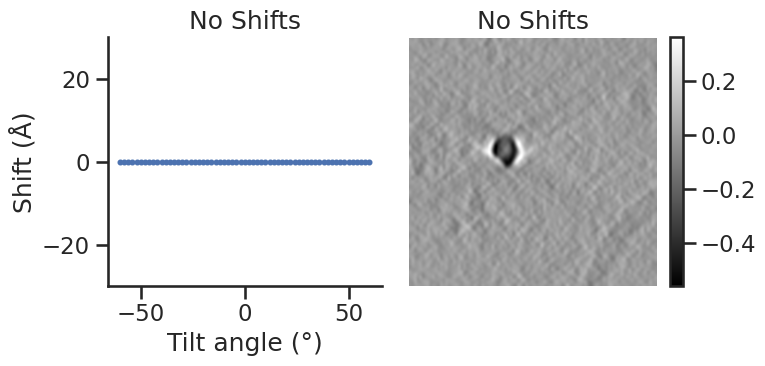

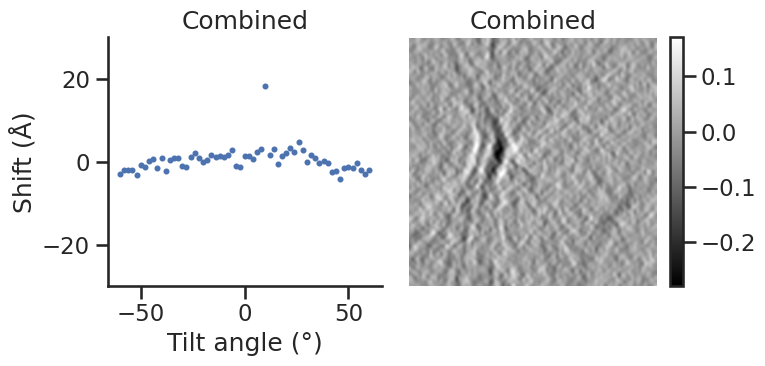

In [10]:
# Create side-by-side plots for each shift type using stored shifts
shift_types = ['Jitter', 'Trajectory', 'Outliers', 'Fractures']

# Get tilt angles for the stored shifts
tilt_angles_actual = tilt_series.angles.cpu().numpy()

for shift_type in shift_types:
    # Create figure with two subplots
    fig, (ax_shift, ax_recon) = plt.subplots(1, 2, figsize=(8, 4))
    
    # Left subplot: Shift pattern (use stored shifts)
    shifts_for_plot = shifts_dict[shift_type].cpu()[:, 0].numpy()
    ax_shift.scatter(tilt_angles_actual, shifts_for_plot, s=8)
    ax_shift.set_ylim(-30, 30)
    ax_shift.set_ylabel('Shift (Å)')
    ax_shift.set_xlabel('Tilt angle (°)')
    ax_shift.set_title(f'{shift_type}')
    sns.despine(ax=ax_shift)
    
    # Right subplot: Reconstruction
    recon = reconstructions[shift_type]
    im = ax_recon.imshow(recon[:, 10].numpy(), cmap='gray', interpolation='spline36')
    ax_recon.set_title(f'{shift_type}')
    ax_recon.axis('off')
    plt.colorbar(im, ax=ax_recon, fraction=0.046)
    
    fig.tight_layout()
    plt.savefig(f'shift_illustration_{shift_type.lower()}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Plot for the no-shift baseline
fig, (ax_shift, ax_recon) = plt.subplots(1, 2, figsize=(8, 4))

# Left subplot: No shifts (flat line at 0)
ax_shift.scatter(tilt_angles_actual, np.zeros(len(tilt_angles_actual)), s=8)
ax_shift.set_ylim(-30, 30)
ax_shift.set_ylabel('Shift (Å)')
ax_shift.set_xlabel('Tilt angle (°)')
ax_shift.set_title('No Shifts')
sns.despine(ax=ax_shift)

# Right subplot: Reconstruction
recon = reconstructions['No shifts']
im = ax_recon.imshow(recon[:, 10].numpy(), cmap='gray', interpolation='spline36')
ax_recon.set_title('No Shifts')
ax_recon.axis('off')
plt.colorbar(im, ax=ax_recon, fraction=0.046)

fig.tight_layout()
plt.savefig('shift_illustration_no_shifts.png', dpi=300, bbox_inches='tight')
plt.show()

# Plot for the combined shifts
fig, (ax_shift, ax_recon) = plt.subplots(1, 2, figsize=(8, 4))

# Left subplot: Combined shift pattern (sum of all shifts)
combined_shifts_for_plot = shifts_dict['Combined'].cpu()[:, 0].numpy()
ax_shift.scatter(tilt_angles_actual, combined_shifts_for_plot, s=8)
ax_shift.set_ylim(-30, 30)  # Increased range for combined shifts
ax_shift.set_ylabel('Shift (Å)')
ax_shift.set_xlabel('Tilt angle (°)')
ax_shift.set_title('Combined')
sns.despine(ax=ax_shift)

# Right subplot: Reconstruction
recon = reconstructions['Combined']
im = ax_recon.imshow(recon[:, 10].numpy(), cmap='gray', interpolation='spline36')
ax_recon.set_title('Combined')
ax_recon.axis('off')
plt.colorbar(im, ax=ax_recon, fraction=0.046)

fig.tight_layout()
plt.savefig('shift_illustration_combined.png', dpi=300, bbox_inches='tight')
plt.show()